# 01 — Exploratory Data Analysis on PhiUSIIL

**Dataset:** PhiUSIIL Phishing URL Dataset (UCI ML Repository, 2024)
- 235,795 URLs — 134,850 legitimate (`label=1`) / 100,945 phishing (`label=0`)
- CC BY 4.0

**Goal of this notebook:** understand URL-length, TLD, HTTPS, and token distributions per class, then save a deduplicated `(URL, label)` parquet for downstream notebooks.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RAW = Path('../data/raw/phiusiil/PhiUSIIL_Phishing_URL_Dataset.csv')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

## Load URL + label only

In [2]:
df = pd.read_csv(RAW, usecols=['URL', 'label'])
print(df.shape)
df.head()

(235795, 2)


,URL,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1


## Class balance, duplicates, nulls

In [3]:
print('Label counts:')
print(df['label'].value_counts())
print(f"Phish rate: {(1 - df['label'].mean()):.3%}")
print(f"Duplicate URLs: {df['URL'].duplicated().sum()}")
print(f"Null URLs:      {df['URL'].isna().sum()}")

Label counts:
label
1    134850
0    100945
Name: count, dtype: int64
Phish rate: 42.810%
Duplicate URLs: 425
Null URLs:      0


## URL length distribution

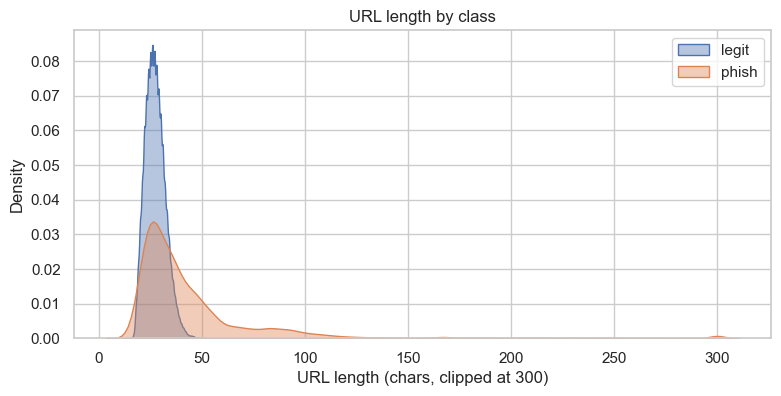

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,46.238774,61.074850,14.0,26.0,34.0,48.0,6097.0
1,134850.0,27.228610,4.815612,16.0,24.0,27.0,30.0,58.0


In [4]:
df['url_len'] = df['URL'].str.len()
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, name in [(1, 'legit'), (0, 'phish')]:
    sns.kdeplot(df.loc[df['label'] == lbl, 'url_len'].clip(upper=300),
                label=name, ax=ax, fill=True, alpha=0.4)
ax.set_xlabel('URL length (chars, clipped at 300)')
ax.set_title('URL length by class')
ax.legend()
plt.show()
df.groupby('label')['url_len'].describe()

## TLD distribution by class

In [5]:
import tldextract
df['tld'] = df['URL'].apply(lambda u: tldextract.extract(u).suffix or '<none>')
top = df['tld'].value_counts().head(15).index
tld_by_class = (df[df['tld'].isin(top)]
                .groupby(['tld', 'label']).size()
                .unstack(fill_value=0)
                .rename(columns={0: 'phish', 1: 'legit'}))
tld_by_class['phish_rate'] = tld_by_class['phish'] / (tld_by_class['phish'] + tld_by_class['legit'])
tld_by_class.sort_values('phish_rate', ascending=False)

label,phish,legit,phish_rate
tld,,,
top,2327,2,0.999141
dev,2312,33,0.985928
app,6368,140,0.978488
co,4918,398,0.925132
io,3769,432,0.897167
ru,2983,892,0.769806
net,3099,3998,0.436663
com,43780,68785,0.388931
fr,492,1336,0.269147


## HTTPS usage by class

In [6]:
df['is_https'] = df['URL'].str.startswith('https://')
(df.groupby('label')['is_https']
   .mean()
   .rename(index={0: 'phish', 1: 'legit'})
   .to_frame('https_rate'))

,https_rate
label,
phish,0.487354
legit,1.000000


## Save processed dataset

Deduplicate on URL string, keep only `URL` and `label`, save as parquet (faster reload + smaller than CSV).

In [7]:
clean = (df[['URL', 'label']]
         .drop_duplicates(subset='URL')
         .reset_index(drop=True))
print(f'After dedupe: {len(clean):,} rows')
out = PROCESSED / 'phiusiil_clean.parquet'
clean.to_parquet(out, index=False)
print(f'Saved -> {out}')

After dedupe: 235,370 rows


Saved -> ..\data\processed\phiusiil_clean.parquet
